In [2]:
# DONT USE

import numpy as np
import cv2
import json
from typing import List
import re
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image
import io
import html
import base64
from IPython.display import display, HTML

def read_n_lines(file_path: str, n: int) -> List[str]:
    with open(file_path, 'r') as file:
        lines = [next(file).strip() for _ in range(n)]
    return lines

def parse_trajectory_tokens(caption):
  caption = caption.strip("\n")
  if ";" in caption:
    raise ValueError
  pattern = r"(?:<loc\d{4}>)+ ([\w\s\-]+)$"
  match = re.search(pattern, caption)
  #print(f"Matched words: {match.group(1)}")
  if match:
    return match
  else:
    return ""

images = []
lines = read_n_lines(f"{dataset_location}/dataset/_annotations.all.jsonl.small", 2)
first = json.loads(lines[0])

#CLASSES = first.get('prefix').replace("detect ", "").split(" ; ")
for line in lines:
    data = json.loads(line)
    #image = cv2.imread(f"{dataset_location}/dataset/{data.get('image')}")
    #(h, w, _) = image.shape

    suffix = data.get('suffix')
    prefix = data.get('prefix')
    #match = parse_trajectory_tokens(suffix)
    print(prefix)
    

move large blue cube onto large blue sphere<loc0406><loc0482><loc0053><loc0101><loc0051><loc0083>
move small purple sphere onto small brown sphere<loc0409><loc0510><loc0050><loc0104><loc0048><loc0076>


In [1]:
import numpy as np
import cv2
import json
from typing import List
import re
from pathlib import Path
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image
import io
import html
import base64
from IPython.display import display, HTML

In [6]:
from droidloader.my_episode_list import imginfo

# Load Max data

data_path = Path("data/clevr-act-8-clevr-rt")
#data_path = Path("data/trajectory")
with open(data_path / "_annotations.all.jsonl", "r") as f:
    lines = [line.strip() for line in f.readlines()]

EPISODE_IDX = 0
info = json.loads(lines[EPISODE_IDX])

camera_intrinsic = np.array(info["camera_intrinsic"][0])
camera_extrinsic = np.array(info["camera_extrinsic"][0])
obj_start_pose = np.array(info["obj_start_pose"][0])

def extract_extrinsics(pose: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Takes a vector with dimension 6 and extracts the translation vector and the rotation matrix"""
    translation = pose[:3]
    rotation = Rotation.from_quat(np.array(pose[3:]), scalar_first=True).as_matrix()
    return (translation, rotation)

obj_start_t, obj_start_rot = extract_extrinsics(obj_start_pose)
image = cv2.imread(data_path / info["image"])[:,:,::-1].astype(np.float32) / 255
caption = info["action_text"]

print(camera_intrinsic)
print(camera_extrinsic)
print(obj_start_pose)
imginfo(image)

[[410.02923584   0.         224.        ]
 [  0.         410.02923584 224.        ]
 [  0.           0.           1.        ]]
[[ 0.90646791 -0.42227489  0.          0.21786498]
 [-0.12521932 -0.26879948 -0.95502198  0.1410865 ]
 [ 0.40328175  0.86569679 -0.29653504  0.5197947 ]]
[-0.15948448  0.10679624  0.02        0.0377393  -0.         -0.
 -0.99928761]
<class 'numpy.ndarray'> float32 (448, 448, 3) 0.03137255 1.0


In [2]:
from droidloader.my_episode_list import date_to_uuid, annotations, imginfo
from droidloader.max_loader import MaxLoader

EPISODE_IDX = 0
loader = MaxLoader()
print("number of episodes:", len(loader))
print("Shuffled episode #0")

print("info:")
print(loader.get_info(EPISODE_IDX))
print("first image:")
imginfo(loader.get_image_grip(EPISODE_IDX))

info = loader.get_info(EPISODE_IDX)
camera_intrinsic = info["camera_intrinsic"]
camera_extrinsic = info["camera_extrinsic"]
obj_start_pose = info["obj_start_pose"]

def extract_extrinsics(pose: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Takes a vector with dimension 6 and extracts the translation vector and the rotation matrix"""
    translation = pose[:3]
    rotation = Rotation.from_quat(np.array(pose[3:]), scalar_first=True).as_matrix()
    return (translation, rotation)

obj_start_t, obj_start_rot = extract_extrinsics(obj_start_pose)

number of episodes: 2
Shuffled episode #0
info:
{'date': '2023-07-07-15h-03m-33s', 'action_text': 'Stack the cups into the orange cup', 'camera_intrinsic': array([[524.4229126 ,   0.        , 639.77502441],
       [  0.        , 524.4229126 , 370.27749634],
       [  0.        ,   0.        ,   1.        ]]), 'camera_extrinsic': array([[-0.59511223, -0.7827559 ,  0.18202924,  0.57351931],
       [-0.42578349,  0.11500408, -0.89748676,  0.40716895],
       [ 0.68157895, -0.61161039, -0.40172487,  0.19179902],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), 'obj_start_pose': array([ 0.51851648, -0.1630991 ,  0.10996298,  0.07909038, -0.98330057,
        0.15969698, -0.03689966]), 'obj_end_pose': array([ 0.63462764, -0.28273192,  0.27360621,  0.0562363 , -0.97885339,
        0.17441472, -0.09090114]), 'tcp_start_pose': array([0.31484374, 0.15407887, 0.42889264, 0.04138981, 0.98461116,
       0.14676198, 0.08537374]), 'grasp_pose': [0.518516480922699, -0.16309909522533417, 0

[[-4.62264060e+02  1.41354220e+01 -6.64238501e+01  1.32970840e+02]
 [-4.51935547e+01 -8.05210824e+01 -4.58010782e+02  1.67843737e+02]
 [-4.67428029e-01 -8.32813385e-01 -2.96535045e-01  5.41999987e-01]]
O [245.33365815 309.67479893]
X [175.15027824 329.77690537]
Y [292.95600287 348.34343286]
Z [246.56840406 238.20337023]



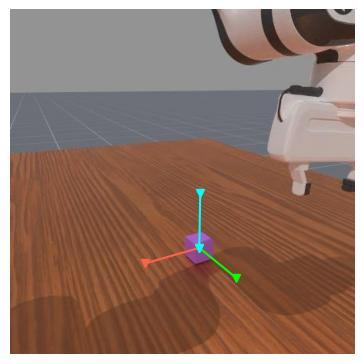

done!


In [7]:
# text = "<loc0625><loc0762><loc0468><loc0724><loc0384><loc0679><loc0375><loc0632><loc0430><loc0587><loc0587> 1"
# action_text = data.get('prefix')

def camera_to_world(t, rot):
    """
    Extrinsic matrix C from local coordinates to world coordinates.
    First rotation, then translation.
    t: (3) translation, world coordinates of local center
    rot: (3,3) rotation
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot
    ext[0:3, 3] = t
    return ext

def world_to_camera(t: np.ndarray, rot: np.ndarray):
    """
    World 3d to camera 3d.
    t: (3) translation
    rot: (3,3) rotation
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot.T
    ext[0:3, 3] = -rot.T @ t
    return ext

def project(point_3d: np.ndarray, proj: np.ndarray):
    """ 
    Multiply projection matrix by point in homogenous coordinates.
    point_3d: (3) 
    proj: (3, 4) """
    p3d = np.ones((4))
    p3d[:3] = point_3d
    p2d = proj @ p3d # (3, 4) x (4, 1)
    p2d = p2d / p2d[2]
    return p2d[:2]

# === Project world to pixels:
# 1) world to camera, C^(-1)
# 2) pinhole
# 3) intrinsic
# 4) divide by last component in homogeneous coordinates

# === Camera
extrinsic = camera_extrinsic
intrinsic = camera_intrinsic
pinhole = np.eye(4)[:3, :4]
camera_proj = intrinsic @ extrinsic # (3, 3) x (3, 4), x (4, 4)

# === Robot extrinsic = [tx ty tz + qw qx qy qz]
flange_t = np.array([0, 0, 0.15]) # [x y z]
flange_transform = camera_to_world(flange_t, np.eye(3))
robot_transform = camera_to_world(obj_start_t, obj_start_rot) # [4, 4]
# multiply robot_transform by flange_transform

def render_example_trajectory(image, caption):
    image_height = 720 # 448, 448
    image_width = 1280

    image_height, image_width = 448, 448
    
    # === Pattern to extract numbers inside <loc####> tags
    # loc_strings = re.findall(r"<loc(\d{4})>", caption)
    # num_position_tokens = len(loc_strings)
    # loc_strings_pairs = loc_strings[:(num_position_tokens//2)*2]
    # loc_numbers = [int(x) for x in loc_strings_pairs]
    # loc_h = [x/1024*image_height for x in loc_numbers[::2]]
    # loc_w = [x/1024*image_width for x in loc_numbers[1::2]]
    # curve_2d_short = curve_2d = np.array([np.stack((loc_w, loc_h), axis=1)])

    # env_id = 0
    # x, y = curve_2d[env_id, :, 0].tolist(), curve_2d[env_id, :, 1].tolist()

    dpi = 100
    figsize = (image_width / dpi, image_height / dpi)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(image)
    ax.axis('off')
    #ax.plot(curve_2d_short[env_id,:1,0], curve_2d_short[env_id, :1,1],'.-', color='lime')
    
    # === plot coordinate system (robot space)
    axes_length = 0.1
    o = np.array([0, 0, 0])
    x = np.array([1, 0, 0]) * axes_length
    y = np.array([0, 1, 0]) * axes_length
    z = np.array([0, 0, 1]) * axes_length
    total_proj = camera_proj @ robot_transform

    o = project(o, total_proj)
    x = project(x, total_proj)
    y = project(y, total_proj)
    z = project(z, total_proj)
    print(total_proj)
    print("O", o)
    print("X", x)
    print("Y", y)
    print("Z", z)
    
    line_x = np.stack((o, x)) # (n_points, xy)
    line_y = np.stack((o, y))
    line_z = np.stack((o, z))
    ax.plot(line_x[:, 0], line_x[:, 1],'v-', color='tomato')
    ax.plot(line_y[:, 0], line_y[:, 1],'v-', color='lime')
    ax.plot(line_z[:, 0], line_z[:, 1],'v-', color='aqua')

    with io.BytesIO() as buffer:
        fig.savefig(buffer, format='jpeg',bbox_inches='tight', dpi=dpi)
        image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
        res_str =  f"data:image/jpeg;base64,{image_b64}"
    plt.close(fig)
    
    # width, height = 224, 224
    return f"""
<div style="display: inline-flex; align-items: center; justify-content: center;">
    <img style="width:640px; height:360px;" src="{res_str}" />
    <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</br>{html.escape(caption)}</p>

</div>
"""

html_out = ""
#for image, _, caption in make_predictions(validation_data_iterator(), num_examples=1, batch_size=1):
#  html_out += render_example(image, caption)

html_out += render_example_trajectory(image, caption)
display(HTML(html_out))
print("done!")

In [13]:
matches[:, 0]

NameError: name 'matches' is not defined